#IS 470 Lab 9: Clustering

---
You have been given a data file by the San Francisco Bay Area Rapid Transit (BART), which identifies a set of demographics for residents in a local area. We will use this file to determine residents segmentations so that we can use it to develop marketing plans accordingly.<br>
<br>
VARIABLE DESCRIPTIONS:<br>
<br>
Age:

            1.   14 thru 17
            2.   18 thru 24
            3.   25 thru 34
            4.   35 thru 44
            5.   45 thru 54
            6.   55 thru 64
            7.   65 and Over

DistToWork: Distance to work in miles<br>
DualInc: Is dual income household or not<br>
Education:

            1. Grade 8 or less<br>
            2. Grades 9 to 11<br>
            3. Graduated high school<br>
            4. 1 to 3 years of college<br>
            5. College graduate<br>
            6. Grad Study<br>
Gender:	M or F<br>
Income:

            1. Less than $10,000<br>
            2. $10,000 to $14,999<br>
            3. $15,000 to $19,999<br>
            4. $20,000 to $24,999<br>
            5. $25,000 to $29,999<br>
            6. $30,000 to $39,999<br>
            7. $40,000 to $49,999<br>
            8. $50,000 to $74,999<br>
            9. $75,000 or more<br>
Language:	Language spoken at home<br>
NbrInHouseHold:	Number in household<br>
NbrInHouseholdUnder18:	Number in household under 18 years old<br>
OwnRent:	Own, rent, or live with parents<br>
YrsInArea:	Years lived in bay area<br>
Rider:	No, Non-rider; Yes, Rider<br>

###1. Upload and clean data

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
from sklearn.cluster import KMeans
from collections import Counter
from sklearn import preprocessing
from matplotlib import pyplot as plt

In [3]:
# Read data
BartRider = pd.read_csv("/content/drive/MyDrive/IS470_data/BartRider.csv")
BartRider

,Age,DistToWork,DualInc,Education,Gender,Income,Language,NbrInHouseHold,NbrInHouseholdUnder18,OwnRent,YrsInArea,Rider
0,3,10,N,4,F,7,English,1,0,Rent,3,Yes
1,3,11,N,4,M,6,English,3,1,Rent,2,No
2,2,10,N,5,M,6,English,2,0,Rent,3,No
3,5,6,Y,5,M,4,English,3,0,Rent,5,No
4,4,9,N,4,F,4,English,3,1,Rent,4,No
...,...,...,...,...,...,...,...,...,...,...,...,...
5488,2,9,N,2,F,1,English,5,1,Parent,6,Yes
5489,2,9,N,2,F,2,Other,4,1,Parent,4,Yes
5490,1,13,N,2,F,2,Spanish,4,2,Parent,1,Yes
5491,4,9,N,3,M,1,English,3,2,Parent,4,Yes


In [4]:
# Show the head rows of a data frame
BartRider.head()

,Age,DistToWork,DualInc,Education,Gender,Income,Language,NbrInHouseHold,NbrInHouseholdUnder18,OwnRent,YrsInArea,Rider
0,3,10,N,4,F,7,English,1,0,Rent,3,Yes
1,3,11,N,4,M,6,English,3,1,Rent,2,No
2,2,10,N,5,M,6,English,2,0,Rent,3,No
3,5,6,Y,5,M,4,English,3,0,Rent,5,No
4,4,9,N,4,F,4,English,3,1,Rent,4,No


In [5]:
# Examine variable type
BartRider.dtypes

,0
Age,int64
DistToWork,int64
DualInc,object
Education,int64
Gender,object
Income,int64
Language,object
NbrInHouseHold,int64
NbrInHouseholdUnder18,int64
OwnRent,object


In [6]:
# Change categorical variables to "category"
BartRider['DualInc'] = BartRider['DualInc'].astype('category')
BartRider['Gender'] = BartRider['Gender'].astype('category')
BartRider['Language'] = BartRider['Language'].astype('category')
BartRider['OwnRent'] = BartRider['OwnRent'].astype('category')
BartRider['Rider'] = BartRider['Rider'].astype('category')

In [7]:
# Examine variable type
BartRider.dtypes

,0
Age,int64
DistToWork,int64
DualInc,category
Education,int64
Gender,category
Income,int64
Language,category
NbrInHouseHold,int64
NbrInHouseholdUnder18,int64
OwnRent,category


###2. Prepare data set for clustering

In [8]:
# Create dummy variables
BartRider = pd.get_dummies(BartRider, columns=['DualInc','Gender','Language','OwnRent','Rider'], drop_first=True)
BartRider

,Age,DistToWork,Education,Income,NbrInHouseHold,NbrInHouseholdUnder18,YrsInArea,DualInc_Y,Gender_M,Language_Other,Language_Spanish,OwnRent_Parent,OwnRent_Rent,Rider_Yes
0,3,10,4,7,1,0,3,False,False,False,False,False,True,True
1,3,11,4,6,3,1,2,False,True,False,False,False,True,False
2,2,10,5,6,2,0,3,False,True,False,False,False,True,False
3,5,6,5,4,3,0,5,True,True,False,False,False,True,False
4,4,9,4,4,3,1,4,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5488,2,9,2,1,5,1,6,False,False,False,False,True,False,True
5489,2,9,2,2,4,1,4,False,False,True,False,True,False,True
5490,1,13,2,2,4,2,1,False,False,False,True,True,False,True
5491,4,9,3,1,3,2,4,False,True,False,False,True,False,True


In [9]:
# Apply minmax normalization
min_max_scaler = preprocessing.MinMaxScaler()
BartRider_normalized = pd.DataFrame(min_max_scaler.fit_transform(BartRider))
BartRider_normalized.columns = BartRider.columns
BartRider_normalized

,Age,DistToWork,Education,Income,NbrInHouseHold,NbrInHouseholdUnder18,YrsInArea,DualInc_Y,Gender_M,Language_Other,Language_Spanish,OwnRent_Parent,OwnRent_Rent,Rider_Yes
0,0.333333,0.35,0.6,0.750,0.0,0.000000,0.2,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.333333,0.40,0.6,0.625,0.4,0.333333,0.1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.166667,0.35,0.8,0.625,0.2,0.000000,0.2,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.666667,0.15,0.8,0.375,0.4,0.000000,0.4,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.500000,0.30,0.6,0.375,0.4,0.333333,0.3,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5488,0.166667,0.30,0.2,0.000,0.8,0.333333,0.5,0.0,0.0,0.0,0.0,1.0,0.0,1.0
5489,0.166667,0.30,0.2,0.125,0.6,0.333333,0.3,0.0,0.0,1.0,0.0,1.0,0.0,1.0
5490,0.000000,0.50,0.2,0.125,0.6,0.666667,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
5491,0.500000,0.30,0.4,0.000,0.4,0.666667,0.3,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 3. Clustering model

In [10]:
# Build a clustering model with n_clusters = 2. Set random_state=0.
model1 = KMeans(n_clusters=2, random_state=0)
model1.fit(BartRider_normalized)

KMeans(n_clusters=2, random_state=0)

In [11]:
# Generate the cluster labels
model1.labels_

array([1, 0, 0, ..., 1, 1, 1], dtype=int32)

In [12]:
# Show cluster size
Counter(model1.labels_)

Counter({np.int32(1): 2185, np.int32(0): 3308})

In [13]:
# Show cluster centroids
pd.DataFrame({'cluster 1':BartRider[model1.labels_==0].mean(axis=0), 'cluster 2':BartRider[model1.labels_==1].mean(axis=0)})

,cluster 1,cluster 2
Age,4.209190,2.375286
DistToWork,11.487001,11.429748
Education,4.302297,3.222426
Income,6.178960,3.605492
NbrInHouseHold,2.586457,3.435698
NbrInHouseholdUnder18,0.529625,0.981236
YrsInArea,4.333132,4.234783
DualInc_Y,0.412031,0.004577
Gender_M,0.462817,0.450343
Language_Other,0.025393,0.048055


Q1. What is the percentage of BART riders for cluster 1 and 2? (1 point)<br> cluster 1 has about 8.5% bart riders, where cluster 2 has about 94% riders

Q2. Use the attributes information of cluster centers to understand the profile of residents. Interpret each cluster based on your understanding. (1 point)<br><br/>The first cluster represents more well off people.  They are older, higher income and have smaller housholds.  They also are more likely to own a home and drive to work.<br/><br/>The second cluster is lower income, have larger households, do not own a home and use public transit

In [14]:
# Build a clustering model with n_clusters = 3 (1 point)
model2 = KMeans(n_clusters=3, random_state=0)
model2.fit(BartRider_normalized)


KMeans(n_clusters=3, random_state=0)

In [15]:
# Generate the cluster labels (1 point)
model2.labels_

array([2, 2, 2, ..., 1, 1, 1], dtype=int32)

In [16]:
# Show cluster size (1 point)
Counter(model2.labels_)

Counter({np.int32(2): 1810, np.int32(0): 2293, np.int32(1): 1390})

In [17]:
# Show cluster centroids (1 point)
pd.DataFrame({'cluster 1':BartRider[model2.labels_==0].mean(axis=0), 'cluster 2':BartRider[model2.labels_==1].mean(axis=0), 'cluster 3':BartRider[model2.labels_==2].mean(axis=0)})

,cluster 1,cluster 2,cluster 3
Age,4.702573,1.813669,3.209945
DistToWork,11.447449,11.428777,11.512707
Education,4.451810,2.761151,3.992818
Income,7.102486,2.932374,4.395580
NbrInHouseHold,2.799389,3.972662,2.277348
NbrInHouseholdUnder18,0.634104,1.265468,0.377348
YrsInArea,4.610118,4.383453,3.824862
DualInc_Y,0.464893,0.003597,0.166851
Gender_M,0.404710,0.423022,0.551934
Language_Other,0.020497,0.061871,0.030939


Q3. Assign a meaningful name to each cluster based on the representative profile of residents in each cluster. Explain the reasons for the name you choose. (1 point)<br/><br/>Cluster 1: Established Old People: based on age, household size (small), income (high) and home ownership status (mostly own homes)<br/><br/>Cluster 2: Young Families: based on age (young), household size (largest)<br/><br/>Cluster 3: DINKS (Double Income No Kids): based on age (old enough to have children but don't), household size (mostly small aka no kids), home ownershipt status (mostly don't have one)



Q4. Based on the cluster size and centroids, which n_clusters (n_clusters=2 or n_clusters=3) you will use, and why? (1 point)<br>I would probably choose 3 clusters simply because I could target the advertizing better that way.  I can imagine there being ads for each of those groups.  While, you could in theory target the two clusters as well, my guess is you would have to make your adverstising more generic and that might not be as effective.

Q5. If we segment residents into 3 clusters, what marketing plans you can use to target each cluster? (1 point)<br/><br/>Old People (Cluster 1):  Use fear to sell the idea of taking the train.  Who wants to get in an accident? What if you have a heart attack while driving etc...<br/><br/>Young Family's (Cluster 2): Focus on the fact that you have so many people all going different directions, do you want to drive them all?  what if they just took the train where they need to go?  problem solved?<br/><br/>DINKS (Cluster 3): These people are hard to target becauase they are very independent.  I would make an arguement for cost.  They mostly don't have kids so why is that?  probably because they can't afford it.  save money, take the train?


## 4. Elbow test to determine optimal number of clusters

Text(0.5, 1.0, 'Elbow Test')

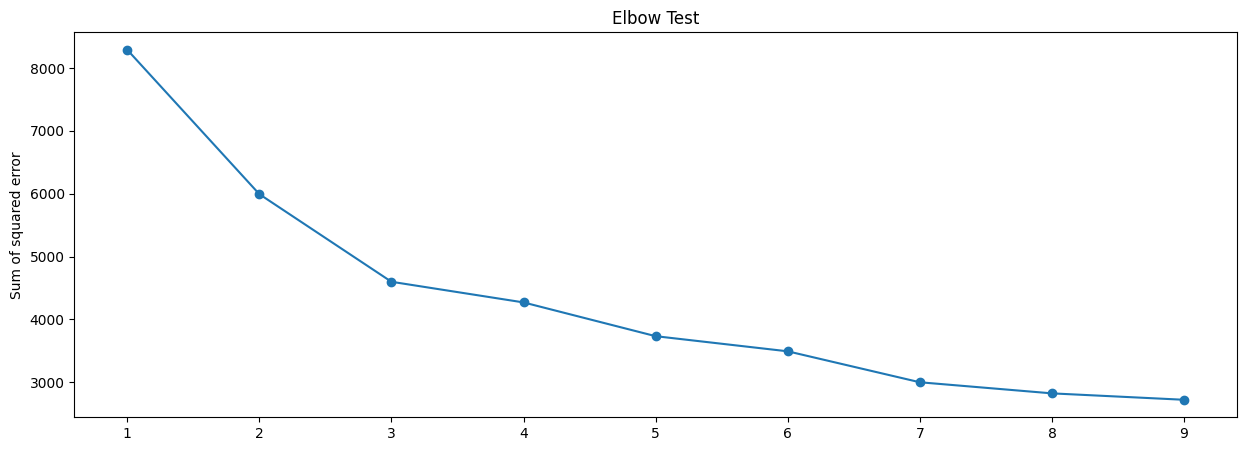

In [18]:
Sum_of_squared_error = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(BartRider_normalized)
    Sum_of_squared_error.append(kmeans.inertia_)

fig = plt.figure(figsize=(15, 5))
plt.scatter(range(1, 10), Sum_of_squared_error)
plt.plot(range(1, 10), Sum_of_squared_error)
plt.ylabel('Sum of squared error')
plt.title('Elbow Test')

Q6. What is the optimal cluster number? (1 point)<br>Based on this, I would say 3 because that appears to be the "elbow" point.

In [20]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/IS470_lab09.ipynb" --to html --output "/content/drive/MyDrive/Output/IS470_Lab09.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470_lab09.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 433561 bytes to /content/drive/MyDrive/Output/IS470_Lab09.html
